In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/youssefkhaled117/used-car-cleaned/Used_Cars_Cleaned.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/youssefkhaled117/used-car-cleaned/Used_Cars_Cleaned.csv')

print(df.head())

           id                  region  price    year manufacturer  model  \
0  7222695916                prescott   6000  2017.0         ford  f-150   
1  7218891961            fayetteville  11900  2017.0         ford  f-150   
2  7221797935            florida keys  21000  2017.0         ford  f-150   
3  7222270760  worcester / central MA   1500  2017.0         ford  f-150   
4  7210384030              greensboro   4900  2017.0         ford  f-150   

  condition    cylinders fuel  odometer title_status transmission drive  \
0      good  8 cylinders  gas  102505.0        clean    automatic   4wd   
1      good  8 cylinders  gas  102505.0        clean    automatic   4wd   
2      good  8 cylinders  gas  102505.0        clean    automatic   4wd   
3      good  8 cylinders  gas  102505.0        clean    automatic   4wd   
4      good  8 cylinders  gas  102505.0        clean    automatic   4wd   

     type paint_color state posting_date  posting_month  
0  pickup       white    az   2021

In [4]:
df.sample(5)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date,posting_month
821,7311306329,birmingham,26991,2019.0,nissan,frontier,good,6 cylinders,gas,12357.0,clean,automatic,rwd,pickup,white,al,2021-04-23,4
75842,7314954055,hartford,22777,2013.0,jeep,wrangler,good,6 cylinders,gas,97822.0,clean,automatic,4wd,SUV,black,ct,2021-04-30,4
5615,7312985115,anchorage / mat-su,20500,2017.0,chrysler,300 limited,excellent,6 cylinders,gas,64261.0,clean,automatic,4wd,sedan,silver,ak,2021-04-26,4
139919,7311429590,indianapolis,12800,2009.0,chevrolet,tahoe,good,6 cylinders,gas,128000.0,lien,manual,4wd,SUV,black,in,2021-04-23,4
291706,7314573066,eugene,12995,2013.0,dodge,durango,excellent,6 cylinders,gas,167528.0,clean,automatic,4wd,SUV,white,or,2021-04-29,4


In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(df.drop('fuel',axis=1),
                                df['fuel'],
                                test_size=0.3,
                                random_state=0)

X_train.shape,X_test.shape

((274408, 17), (117604, 17))

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

# 1️⃣ Identify features and target
X = df.drop('fuel', axis=1)
y = df['fuel']

# 2️⃣ Encode categorical features (like city)
categorical_cols = X.select_dtypes(include='object').columns
for col in categorical_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

# 3️⃣ Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# 4️⃣ Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
scaler.mean_

array([7.31147943e+09, 1.93628054e+02, 1.87804807e+04, 2.01107264e+03,
       1.85717071e+01, 1.58018192e+04, 1.56365704e+00, 4.62945322e+00,
       9.42297379e+04, 1.30455380e-01, 3.73545961e-01, 7.11666569e-01,
       6.11465774e+00, 5.88284598e+00, 2.36251458e+01, 1.92376133e+01,
       4.25666161e+00])

In [8]:
X_train

,id,region,price,year,manufacturer,model,condition,cylinders,odometer,title_status,transmission,drive,type,paint_color,state,posting_date,posting_month
340199,7315816268,72,39990,2018.0,14,23000,2,6,45123.0,0,0,0,8,10,43,28,5
189653,7309259065,163,15775,2017.0,13,12828,2,3,67761.0,0,0,1,0,9,22,15,4
312117,7308010239,311,500,2015.0,3,21017,2,5,85000.0,0,0,0,0,0,38,12,4
206842,7306423631,341,5500,2002.0,20,18027,2,5,133000.0,0,0,0,0,4,24,9,4
279768,7305728460,360,46990,2019.0,4,3203,2,5,14900.0,0,2,0,9,10,35,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359783,7305756855,118,950,1996.0,13,13135,2,6,200000.0,0,0,0,0,10,45,8,4
358083,7302017810,375,18998,2017.0,31,21872,0,3,36859.0,0,0,0,0,8,46,1,4
152315,7314658815,166,10900,2012.0,25,11450,3,5,131000.0,0,0,0,0,0,16,25,4
117952,7315534155,139,33888,2018.0,26,10221,2,3,12007.0,0,0,1,3,5,11,27,5


In [9]:
X_train_scaled

array([[ 0.97179901, -1.03144227,  1.44645738, ...,  1.27911823,
         1.01131304,  1.70181685],
       [-0.49754098, -0.25973506, -0.20496927, ..., -0.10729131,
        -0.4890852 , -0.5876073 ],
       [-0.77737829,  0.99534921, -1.24670134, ...,  0.94902072,
        -0.83533095, -0.5876073 ],
       ...,
       [ 0.7124366 , -0.23429416, -0.53743695, ..., -0.50340833,
         0.66506729, -0.5876073 ],
       [ 0.90858305, -0.46326224,  1.03031014, ..., -0.83350584,
         0.89589779,  1.70181685],
       [ 0.90630819,  0.63069635, -0.10778641, ...,  0.94902072,
         0.89589779,  1.70181685]])

In [10]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [11]:
np.round(X_train.describe(),1)

,id,region,price,year,manufacturer,model,condition,cylinders,odometer,title_status,transmission,drive,type,paint_color,state,posting_date,posting_month
count,2.744080e+05,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0
mean,7.311479e+09,193.6,18780.5,2011.1,18.6,15801.8,1.6,4.6,94229.7,0.1,0.4,0.7,6.1,5.9,23.6,19.2,4.3
std,4.462694e+06,117.9,14663.1,9.5,11.5,7426.0,0.9,1.2,72470.8,0.7,0.7,0.8,4.0,4.2,15.1,8.7,0.4
min,7.209055e+09,0.0,1.0,1900.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
25%,7.308116e+09,82.0,7100.0,2008.0,10.0,10431.8,1.0,3.0,38563.8,0.0,0.0,0.0,2.0,1.0,9.0,13.0,4.0
50%,7.312623e+09,197.0,15154.5,2013.0,14.0,15963.5,2.0,5.0,87268.0,0.0,0.0,1.0,8.0,8.0,23.0,21.0,4.0
75%,7.315251e+09,290.0,27590.0,2017.0,28.0,22461.0,2.0,6.0,135211.2,0.0,0.0,1.0,9.0,10.0,37.0,27.0,5.0
max,7.317098e+09,403.0,119999.0,2022.0,41.0,27945.0,5.0,7.0,1110000.0,5.0,2.0,2.0,12.0,11.0,50.0,30.0,5.0


In [12]:
np.round(X_train_scaled.describe(),1)

,id,region,price,year,manufacturer,model,condition,cylinders,odometer,title_status,transmission,drive,type,paint_color,state,posting_date,posting_month
count,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0,274408.0
mean,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-23.0,-1.6,-1.3,-11.7,-1.6,-2.1,-1.7,-3.8,-1.3,-0.2,-0.5,-0.9,-1.5,-1.4,-1.6,-2.2,-0.6
25%,-0.8,-0.9,-0.8,-0.3,-0.7,-0.7,-0.6,-1.3,-0.8,-0.2,-0.5,-0.9,-1.0,-1.2,-1.0,-0.7,-0.6
50%,0.3,0.0,-0.2,0.2,-0.4,0.0,0.5,0.3,-0.1,-0.2,-0.5,0.4,0.5,0.5,-0.0,0.2,-0.6
75%,0.8,0.8,0.6,0.6,0.8,0.9,0.5,1.1,0.6,-0.2,-0.5,0.4,0.7,1.0,0.9,0.9,1.7
max,1.3,1.8,6.9,1.2,1.9,1.6,3.7,1.9,14.0,6.7,2.2,1.7,1.5,1.2,1.7,1.2,1.7


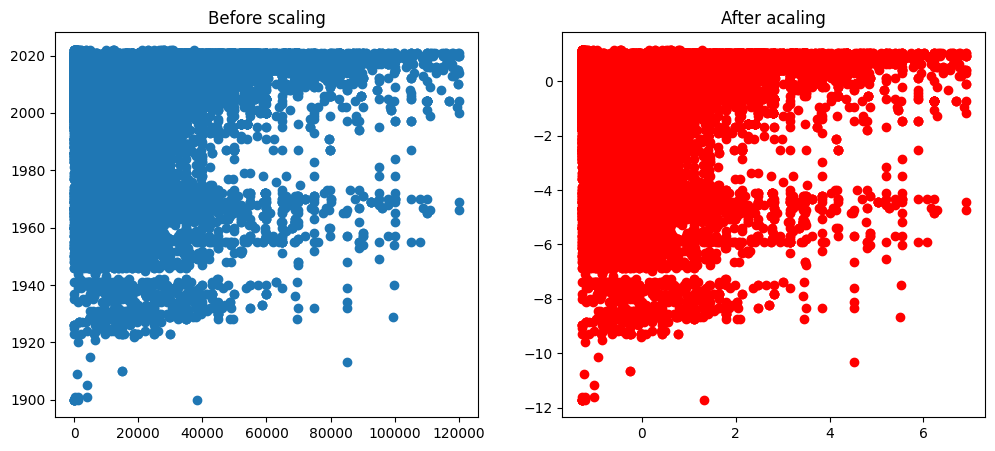

In [13]:
fig,(ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train['price'], X_train['year'])
ax1.set_title('Before scaling')
ax2.scatter(X_train_scaled['price'], X_train_scaled['year'],color='red')
ax2.set_title('After acaling')
plt.show()

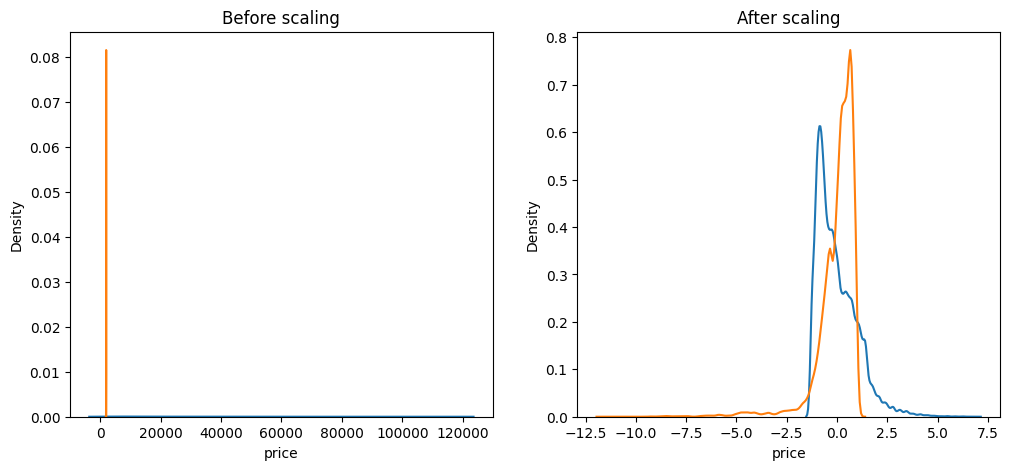

In [14]:
fig,(ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title('Before scaling')
sns.kdeplot(X_train['price'], ax=ax1)
sns.kdeplot(X_train['year'], ax=ax1)

ax2.set_title('After scaling')
sns.kdeplot(X_train_scaled['price'], ax=ax2)
sns.kdeplot(X_train_scaled['year'], ax=ax2)
plt.show()

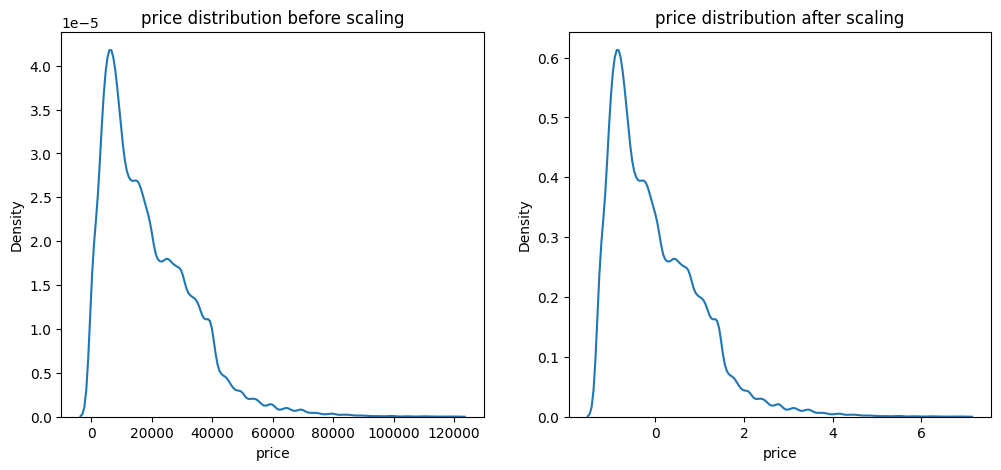

In [15]:
fig,(ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("price distribution before scaling")
sns.kdeplot(X_train['price'], ax=ax1)

ax2.set_title("price distribution after scaling")
sns.kdeplot(X_train_scaled['price'], ax=ax2)
plt.show()

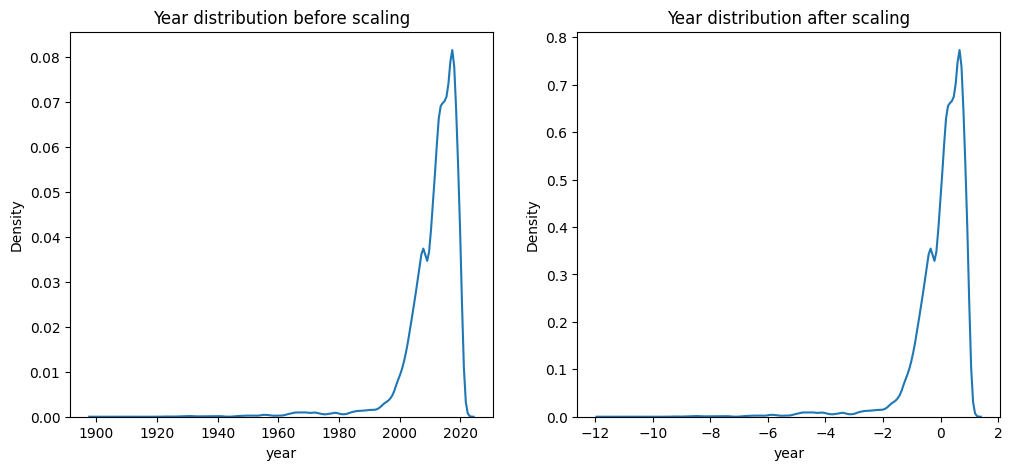

In [16]:
fig,(ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Year distribution before scaling")
sns.kdeplot(X_train['year'], ax=ax1)

ax2.set_title("Year distribution after scaling")
sns.kdeplot(X_train_scaled['year'], ax=ax2)
plt.show()

****WHY SCALING IS IMPORTANT?****

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [19]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [20]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
print("actual",accuracy_score(y_test,y_pred))
print("scaled",accuracy_score(y_test,y_pred_scaled))

actual 0.844180470052039
scaled 0.8580235366144009


In [23]:
from sklearn.tree import DecisionTreeClassifier


In [24]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [25]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [26]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [27]:
print("actual",accuracy_score(y_test,y_pred))
print("sacled",accuracy_score(y_test,y_pred_scaled))

actual 0.9353848508554131
sacled 0.9347386143328458


In [28]:
df.describe()

,id,price,year,odometer,posting_month
count,3.920120e+05,392012.000000,392012.000000,3.920120e+05,392012.000000
mean,7.311479e+09,18790.591836,2011.070324,9.420378e+04,4.256344
std,4.472080e+06,14677.465265,9.496469,7.243350e+04,0.436615
min,7.207408e+09,1.000000,1900.000000,1.000000e+00,4.000000
25%,7.308124e+09,7195.000000,2008.000000,3.866900e+04,4.000000
50%,7.312618e+09,15111.000000,2013.000000,8.731550e+04,4.000000
75%,7.315249e+09,27590.000000,2017.000000,1.350682e+05,5.000000
max,7.317101e+09,119999.000000,2022.000000,1.110000e+06,5.000000


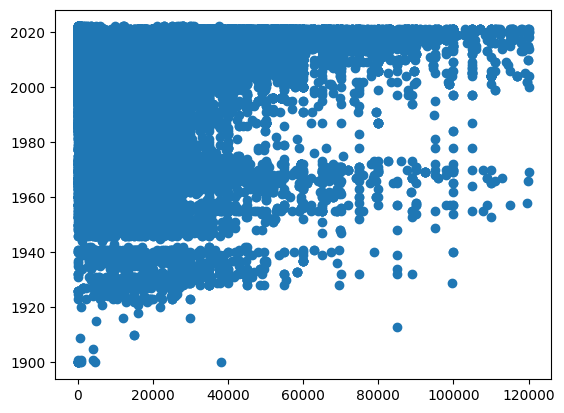

In [29]:
plt.scatter(df['price'],df['year'])